In [1]:
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

c:\Users\phili\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
reviews = pd.read_csv("reviews.csv")
print(reviews.shape)

def clean_text(text):
    text = str(text)
    text = re.sub(r"<br\s*/?>", " ", text)   # HTML line breaks
    text = text.replace("\r", " ")
    return re.sub(r"\s+", " ", text).strip()

reviews["comments_clean"] = reviews["comments"].fillna("").apply(clean_text)
reviews = reviews[reviews["comments_clean"].str.len() > 0].reset_index(drop=True)
print(f"Reviews mit Text: {len(reviews):,}")

(685106, 6)
Reviews mit Text: 685,073


In [3]:
MODEL_NAME = "lxyuan/distilbert-base-multilingual-cased-sentiments-student"
PER_LISTING_CAP = 30       # None = alle Reviews verwenden (dauert auf CPU sehr lange)
BATCH_SIZE = 64
MAX_LENGTH = 128           # Reviews sind meist kurz (Median ~29 Woerter)
CHECKPOINT_PATH = Path("sentiment_checkpoint.csv")
RANDOM_STATE = 42

In [4]:
if PER_LISTING_CAP is not None:
    sampled = (
        reviews.groupby("listing_id", group_keys=False)
        .apply(lambda g: g.sample(min(len(g), PER_LISTING_CAP), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )
else:
    sampled = reviews.copy()

print(f"Reviews in der Stichprobe: {len(sampled):,} / {len(reviews):,} "
      f"({len(sampled) / len(reviews):.1%})")
print(f"Listings abgedeckt: {sampled['listing_id'].nunique():,} / {reviews['listing_id'].nunique():,}")

Reviews in der Stichprobe: 160,537 / 685,073 (23.4%)
Listings abgedeckt: 7,490 / 7,490


C:\Users\phili\AppData\Local\Temp\ipykernel_29120\58775767.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), PER_LISTING_CAP), random_state=RANDOM_STATE))


In [ ]:
import torch
from transformers import pipeline

torch.set_num_threads(8)  # ggf. an eigene CPU-Kernzahl anpassen

device = 0 if torch.cuda.is_available() else -1
print("Device:", "GPU" if device == 0 else "CPU")

classifier = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    truncation=True,
    max_length=MAX_LENGTH,
    device=device,
)

Device: CPU


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3265.30it/s]


In [6]:
test_sample = sampled["comments_clean"].sample(200, random_state=RANDOM_STATE).tolist()

t0 = time.time()
test_out = classifier(test_sample, batch_size=BATCH_SIZE)
dt = time.time() - t0

throughput = len(test_sample) / dt
est_hours = len(sampled) / throughput / 3600

print(f"Durchsatz: {throughput:.1f} Texte/Sekunde")
print(f"Geschaetzte Laufzeit fuer {len(sampled):,} Reviews: {est_hours:.1f} Stunden")
print()
for text, res in list(zip(test_sample, test_out))[:5]:
    print(f"[{res['label']:>8}] ({res['score']:.2f})  {text[:80]}")

Durchsatz: 14.0 Texte/Sekunde
Geschaetzte Laufzeit fuer 160,537 Reviews: 3.2 Stunden

[positive] (0.99)  todo perfecto!!!
[positive] (0.99)  la estancia fue muy buena, pasamos un fin de semana en el alojamiento, con todos
[positive] (0.94)  Le logement est à quelques pas du centre ville historique de Séville. Très propr
[positive] (0.99)  一切都很好，交通便利，公寓很干净，与友好的房主沟通顺畅。
[positive] (0.95)  Norberto est un hôte très généreux, disponible, de bon conseil, prêt à discuter,


In [7]:
if CHECKPOINT_PATH.exists():
    done = pd.read_csv(CHECKPOINT_PATH)
    done_ids = set(done["id"])
    print(f"Checkpoint gefunden: {len(done):,} Reviews bereits verarbeitet")
else:
    done = pd.DataFrame(columns=["id", "label", "score"])
    done_ids = set()

todo = sampled[~sampled["id"].isin(done_ids)].reset_index(drop=True)
print(f"Noch zu verarbeiten: {len(todo):,}")

results = []
write_header = not CHECKPOINT_PATH.exists()

for start in tqdm(range(0, len(todo), BATCH_SIZE), desc="Sentiment-Inferenz"):
    chunk = todo.iloc[start:start + BATCH_SIZE]
    out = classifier(chunk["comments_clean"].tolist(), batch_size=BATCH_SIZE)

    chunk_result = pd.DataFrame({
        "id": chunk["id"].values,
        "label": [o["label"] for o in out],
        "score": [o["score"] for o in out],
    })
    chunk_result.to_csv(CHECKPOINT_PATH, mode="a", header=write_header, index=False)
    write_header = False
    results.append(chunk_result)

if results:
    done = pd.concat([done] + results, ignore_index=True)

print(f"Fertig. Insgesamt verarbeitet: {len(done):,}")

Noch zu verarbeiten: 160,537


Sentiment-Inferenz: 100%|██████████| 2509/2509 [2:38:03<00:00,  3.78s/it]  


Fertig. Insgesamt verarbeitet: 160,537


C:\Users\phili\AppData\Local\Temp\ipykernel_29120\123513234.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  done = pd.concat([done] + results, ignore_index=True)


In [8]:
label_sign = {"positive": 1, "neutral": 0, "negative": -1}

sentiment = done.copy()
sentiment["sentiment_score"] = sentiment["label"].map(label_sign) * sentiment["score"]

sampled_scored = sampled.merge(sentiment[["id", "label", "score", "sentiment_score"]], on="id", how="inner")
print(f"Reviews mit Sentiment-Score: {len(sampled_scored):,}")
sampled_scored[["listing_id", "comments_clean", "label", "sentiment_score"]].head(10)

Reviews mit Sentiment-Score: 160,537


,listing_id,comments_clean,label,sentiment_score
0,49287,The location of the house was in a very cool n...,positive,0.704519
1,49287,"This place has a great location, with a plaza ...",positive,0.914534
2,49287,The location is excellent - very close to hist...,positive,0.845620
3,49287,El apartamento tiene una ubicacion inmejorable...,positive,0.817212
4,49287,"Great location,very comfortable. Walter is ver...",positive,0.902865
5,49287,This place is a fantastic location close to re...,positive,0.825037
6,49287,Had a great stay. Would highly recommend.,positive,0.876814
7,49287,La casa è accogliente e ben equipaggiata. Puli...,positive,0.798749
8,49287,"A estadia foi ótima! Casa limpa e organizada, ...",positive,0.767470
9,49287,Nous avons été très bien accueillies par Walte...,positive,0.974145


In [9]:
listing_sentiment = (
    sampled_scored.groupby("listing_id")
    .agg(
        num_reviews_sampled=("sentiment_score", "count"),
        avg_sentiment_score=("sentiment_score", "mean"),
    )
    .reset_index()
)

# Gesamtzahl Reviews pro Listing (unabhaengig vom Cap) zur Einordnung dazunehmen
total_counts = reviews.groupby("listing_id").size().rename("num_reviews_total")
listing_sentiment = listing_sentiment.merge(total_counts, on="listing_id", how="left")

listing_sentiment["avg_sentiment_score"] = listing_sentiment["avg_sentiment_score"].round(4)

print(f"Listings: {len(listing_sentiment):,}")
print(f"\nScore-Verteilung:\n{listing_sentiment['avg_sentiment_score'].describe().round(3)}")
listing_sentiment.head(10)

Listings: 7,490

Score-Verteilung:
count    7490.000
mean        0.716
std         0.215
min        -0.981
25%         0.670
50%         0.760
75%         0.829
max         0.996
Name: avg_sentiment_score, dtype: float64


,listing_id,num_reviews_sampled,avg_sentiment_score,num_reviews_total
0,49287,30,0.8067,40
1,108236,30,0.7995,222
2,111140,30,0.5476,63
3,159596,1,0.7652,1
4,179629,30,0.7798,205
5,185356,30,0.6042,120
6,207702,30,0.7747,508
7,227905,30,0.7552,238
8,253430,30,0.7846,331
9,266016,30,0.7469,459


In [10]:
print("=== Top 5 positivste Listings ===")
display(listing_sentiment.nlargest(5, "avg_sentiment_score")[
    ["listing_id", "num_reviews_sampled", "num_reviews_total", "avg_sentiment_score"]
])

print("\n=== Top 5 negativste Listings ===")
display(listing_sentiment.nsmallest(5, "avg_sentiment_score")[
    ["listing_id", "num_reviews_sampled", "num_reviews_total", "avg_sentiment_score"]
])

=== Top 5 positivste Listings ===


,listing_id,num_reviews_sampled,num_reviews_total,avg_sentiment_score
6131,1179036341163130184,1,1,0.9956
4805,868707266982444580,1,1,0.9952
5154,975744920850338939,1,1,0.9947
7238,1415059084498300173,1,1,0.9940
2318,38142233,1,1,0.9936



=== Top 5 negativste Listings ===


,listing_id,num_reviews_sampled,num_reviews_total,avg_sentiment_score
7427,1482396819090421231,1,1,-0.9813
3191,51303230,1,1,-0.9467
5673,1101240476035271302,1,1,-0.9425
5500,1070182575473821222,1,1,-0.9375
7384,1464586630685108571,1,1,-0.9322


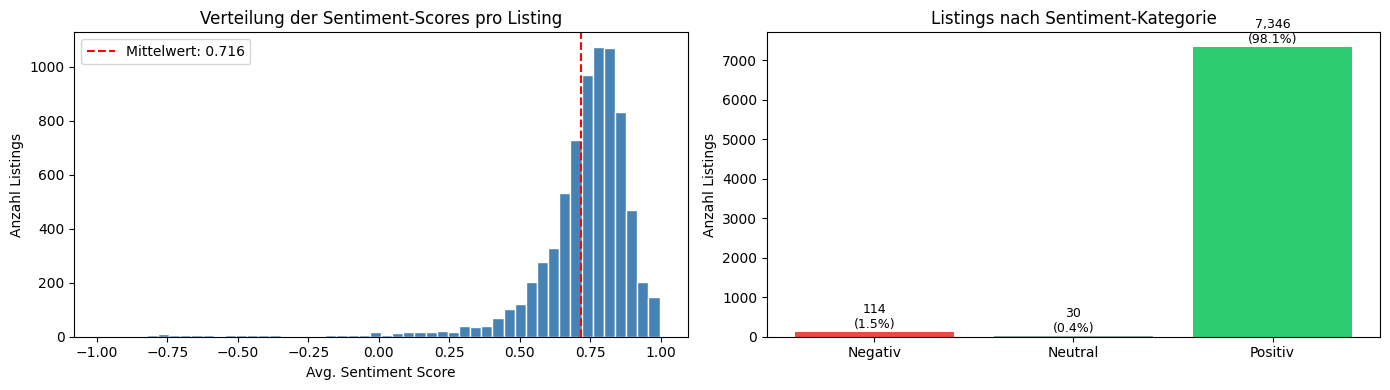

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(listing_sentiment["avg_sentiment_score"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(
    listing_sentiment["avg_sentiment_score"].mean(),
    color="red", linestyle="--",
    label=f"Mittelwert: {listing_sentiment['avg_sentiment_score'].mean():.3f}",
)
axes[0].set_title("Verteilung der Sentiment-Scores pro Listing")
axes[0].set_xlabel("Avg. Sentiment Score")
axes[0].set_ylabel("Anzahl Listings")
axes[0].legend()

bins = [-1, -0.05, 0.05, 1]
labels = ["Negativ", "Neutral", "Positiv"]
listing_sentiment["sentiment_label"] = pd.cut(listing_sentiment["avg_sentiment_score"], bins=bins, labels=labels)
counts = listing_sentiment["sentiment_label"].value_counts().reindex(labels)
colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
axes[1].bar(counts.index, counts.values, color=colors)
axes[1].set_title("Listings nach Sentiment-Kategorie")
axes[1].set_ylabel("Anzahl Listings")
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 20, f"{val:,}\n({val / len(listing_sentiment) * 100:.1f}%)",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 9. Export für Weiterverwendung (z.B. Join mit `listings.csv`)

In [12]:
listing_sentiment.to_csv("listing_sentiment_multilingual.csv", index=False)
print("Gespeichert: listing_sentiment_multilingual.csv")

Gespeichert: listing_sentiment_multilingual.csv
